In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Creating the original Function f^*(x)
"""
This is the true function that is observed in (supposed to be) nature!! (We are just simulating it!!)
"""
coeffs = [3,4,6,5]
input_dim = len([3,4,6,5])
true_params = np.array(coeffs, dtype=np.float16)

def f(x): return np.matmul(true_params, x)

In [3]:
# Our Observations

# Defining our parameters for a normal distribution
mean = np.array([0.5, 3, 4], np.float16)
cov = np.random.rand(3,3)
cov = cov @ cov.T
sample_size = 10000

x_vals = np.random.multivariate_normal(mean, cov, sample_size).T

np.ones(sample_size).shape, x_vals.shape

x_vals = np.vstack((x_vals, np.ones(sample_size)))
x_vals.shape

(4, 10000)

In [4]:
f(x_vals).shape

(10000,)

In [5]:
# Our Y-observations: f(x) + some noise

# Noise configuration
noise_mean = 0  # Why not otherwise??
noise_std = 3

y_vals = f(x_vals) + np.random.normal(0, noise_std, sample_size)

In [6]:
y_vals.shape, x_vals.shape

((10000,), (4, 10000))

In [7]:
# This is now where our algorithm and model come in!!

"""
The point of *Supervised Learning* is that, given this data, can we faithfully reconstruct our original dataset?

Step-1: Guess what the original type function was?? (Hypothesis Set: Let's try linear!!)
Step-2: Define what Good or Bad is?? (Loss function!!)
Step-3: Now, from the hypothesis set, can we find the best function that fits this?? (Learning Algorithm!!)
"""

# Step-1: Hypothesis Set: Linear
model_params = np.random.rand(input_dim)
def hypothesis(x): return np.matmul(model_params, x)

model_params

array([0.27718351, 0.07846496, 0.71901451, 0.6380309 ])

In [8]:
# Step-2: Loss function: MSE (Mean Squared Error)
def MSE(y_true, y_pred): return np.sum((y_true - y_pred)**2)

pred_initial = hypothesis(x_vals)
MSE(y_vals, pred_initial)

np.float64(15617635.909096012)

In [9]:
x_vals.shape, y_vals.shape, hypothesis(x_vals).shape, model_params.shape

((4, 10000), (10000,), (10000,), (4,))

In [10]:
def grad():
    errors = hypothesis(x_vals) - y_vals   # shape (N,)
    return (2 / len(y_vals)) * x_vals @ errors

learning_rate=1e-3

n_iter = 1000

In [11]:
MSE_val = []

for i in range(n_iter):
    # SGD update FIRST
    model_params -= learning_rate * grad()
    MSE_val.append(MSE(y_vals, hypothesis(x_vals)))

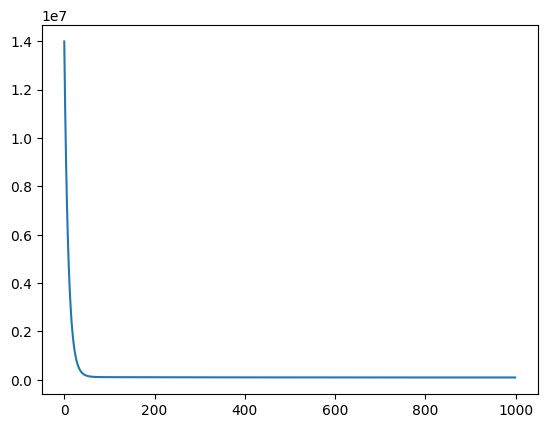

In [12]:
plt.plot(MSE_val)

In [13]:
# We can now also see how this is actually slow and inefficient!! 
# (Most of the time, actually reaching the optimal hypothesis set is very difficult, like this)

# For Linear Regression, we don't actually need SGD at all, a closed-form solution already exists!!!
best_params = np.linalg.inv(x_vals @ x_vals.T) @ x_vals @ y_vals

In [14]:
best_params

array([2.95732967, 4.11707371, 6.02338345, 4.57543683])

In [15]:
true_params

array([3., 4., 6., 5.], dtype=float16)